In [2]:
from google.colab import drive

drive.mount('/content/drive/')

Mounted at /content/drive/


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras

In [4]:
path = '/content/drive/MyDrive/dataset_dl_lab/REI_dataset'

In [5]:
room_types = os.listdir(path)
print(room_types)
print("Number of room categories:", len(room_types))

['README.docx', 'livingRoom', 'kitchen', 'bathroom', 'backyard', 'frontyard', 'bedroom']
Number of room categories: 7


In [6]:
rooms = []

for item in os.listdir(path):

    folder_path = os.path.join(path, item)

    if os.path.isdir(folder_path):

        for file in os.listdir(folder_path):

            image_path = os.path.join(folder_path, file)

            rooms.append([item, image_path])

rooms_df = pd.DataFrame(rooms, columns=['room_type', 'image'])

rooms_df.head()

,room_type,image
0,livingRoom,/content/drive/MyDrive/dataset_dl_lab/REI_data...
1,livingRoom,/content/drive/MyDrive/dataset_dl_lab/REI_data...
2,livingRoom,/content/drive/MyDrive/dataset_dl_lab/REI_data...
3,livingRoom,/content/drive/MyDrive/dataset_dl_lab/REI_data...
4,livingRoom,/content/drive/MyDrive/dataset_dl_lab/REI_data...


In [7]:
print("Total Images:", len(rooms_df))
print("\nImages Per Category:\n")
print(rooms_df['room_type'].value_counts())

Total Images: 5859

Images Per Category:

room_type
bedroom       1593
kitchen        992
frontyard      884
livingRoom     852
bathroom       793
backyard       745
Name: count, dtype: int64


In [8]:
im_size = 128

images = []
labels = []

for category in os.listdir(path):

    category_path = os.path.join(path, category)

    # Ignore files like README.docx
    if os.path.isdir(category_path):

        for file in os.listdir(category_path):

            img_path = os.path.join(category_path, file)

            img = cv2.imread(img_path)

            # Ignore corrupted images
            if img is not None:

                img = cv2.resize(img, (im_size, im_size))

                images.append(img)

                labels.append(category)

In [9]:
images = np.array(images, dtype='float32')
labels = np.array(labels)
print(images.shape)
print(labels.shape)

(5859, 128, 128, 3)
(5859,)


In [10]:
images = images / 255.0

In [11]:
encoder = LabelEncoder()

y = encoder.fit_transform(labels)

print(y[:10])

[5 5 5 5 5 5 5 5 5 5]


In [12]:
y = keras.utils.to_categorical(y)
print(y.shape)

(5859, 6)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    images,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
X_train = X_train.reshape(X_train.shape[0], -1)

X_test = X_test.reshape(X_test.shape[0], -1)

print(X_train.shape)

(4687, 49152)


In [15]:
model = keras.Sequential([

    keras.layers.Dense(
        512,
        activation='relu',
        input_shape=(X_train.shape[1],)
    ),

    keras.layers.Dropout(0.3),

    keras.layers.Dense(256, activation='relu'),

    keras.layers.Dropout(0.3),

    keras.layers.Dense(y.shape[1], activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │    25,166,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,299,206 (96.51 MB)

 Trainable params: 25,299,206 (96.51 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3672 - loss: 1.4895 - val_accuracy: 0.4104 - val_loss: 1.3334
Epoch 2/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3683 - loss: 1.4907 - val_accuracy: 0.3746 - val_loss: 1.5011
Epoch 3/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.3648 - loss: 1.5014 - val_accuracy: 0.4053 - val_loss: 1.3285
Epoch 4/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3578 - loss: 1.5101 - val_accuracy: 0.4002 - val_loss: 1.3453
Epoch 5/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.3678 - loss: 1.4916 - val_accuracy: 0.3780 - val_loss: 1.4275
Epoch 6/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3680 - loss: 1.4887 - val_accuracy: 0.4019 - val_loss: 1.3280
Epoch 7/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3665 - loss: 1.4927 - val_accuracy: 0.4027 - val_loss: 1.3346
Epoch 8/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.3757 - loss: 1.4585 - val_accu

In [23]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4010 - loss: 1.3312
Test Accuracy: 0.40102389454841614


In [24]:
predictions = model.predict(X_test)
predicted_class = np.argmax(predictions, axis=1)
actual_class = np.argmax(y_test, axis=1)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


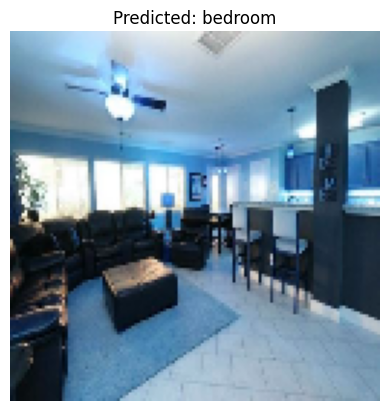

In [25]:
plt.imshow(X_test[0].reshape(128,128,3))

plt.title(
    "Predicted: " +
    encoder.inverse_transform([predicted_class[0]])[0]
)

plt.axis('off')

plt.show()